# Phase 1 Capstone — End-to-End Data Analysis
# Ames Housing Dataset

## Objective

This project analyzes the Ames housing dataset to understand which
property characteristics and neighborhood factors are most strongly
associated with house sale prices.

## Primary Question

**Which property characteristics are most strongly associated with house sale prices in the Ames housing dataset?**

## Supporting Questions

1. Is above-ground living area (`GrLivArea`) strongly associated with `SalePrice`?
2. Do houses with different overall quality levels (`OverallQual`) have meaningfully different sale prices?
3. Does sale price differ substantially across neighborhoods?

## Decision Context

This analysis is useful to buyers, sellers, property analysts, and other
real-estate decision-makers who want to understand which measurable
property characteristics and locations are associated with higher or lower
sale prices.

The results can help identify important price patterns, compare typical
prices across neighborhoods, and understand whether property quality and
living area are associated with sale price.

## Evidence Criteria

Before examining the results, the analysis will treat a relationship as
meaningful when it is supported by clear exploratory patterns and, where
appropriate, statistical evidence.

For the hypothesis tests, the significance level is **α = 0.05**.
Statistical significance will be interpreted together with an effect size,
because a small p-value alone does not show whether a difference is
practically important.

# 1. Import Libraries

We use pandas for data manipulation, NumPy for numerical operations,
Matplotlib and Seaborn for visualization, and SciPy for statistical
analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import os

os.makedirs("figures", exist_ok=True)  # charts are saved here
pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load Dataset

The dataset contains residential property records from Ames.
We preserve the original dataset and will create a separate
cleaned version later.

In [2]:
df = pd.read_csv("ames_housing.csv")


# 3. Initial Data Assessment
# 3.1 Dataset Shape

We first determine the number of observations and variables.

In [3]:
rows, columns = df.shape

print(f"Number of rows    : {rows}")
print(f"Number of columns : {columns}")

Number of rows    : 1460
Number of columns : 11


In [4]:
df.head()


,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
0,1,BrkSide,4,1726,1963,4,1,2,9055,188300,64.0
1,2,CollgCr,6,2292,1921,5,2,2,12134,267200,42.0
2,3,BrkSide,5,2063,2001,3,2,2,9699,254400,77.0
3,4,Edwards,6,2379,1952,4,1,3,16192,230600,NaN
4,5,NoRidge,8,2339,1996,4,2,2,10937,390200,74.0


In [5]:
df.tail()

,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
1455,1456,NoRidge,5,1500,1989,3,2,1,10117,319600,55.0
1456,1457,Veenker,5,1853,1990,4,2,2,6720,287800,58.0
1457,1458,CollgCr,5,1635,2001,3,2,1,9898,239700,NaN
1458,1459,MeadowV,3,1450,2003,4,3,1,16762,135200,89.0
1459,1460,NWAmes,6,1892,1913,3,2,1,11449,218200,NaN


In [6]:
df.columns

Index(['Id', 'Neighborhood', 'OverallQual', 'GrLivArea', 'YearBuilt',
       'Bedrooms', 'FullBath', 'GarageCars', 'LotArea', 'SalePrice',
       'LotFrontage'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   Neighborhood  1460 non-null   str    
 2   OverallQual   1460 non-null   int64  
 3   GrLivArea     1460 non-null   int64  
 4   YearBuilt     1460 non-null   int64  
 5   Bedrooms      1460 non-null   int64  
 6   FullBath      1460 non-null   int64  
 7   GarageCars    1460 non-null   int64  
 8   LotArea       1460 non-null   int64  
 9   SalePrice     1460 non-null   int64  
 10  LotFrontage   1212 non-null   float64
dtypes: float64(1), int64(9), str(1)
memory usage: 125.6 KB


### Data Dictionary

| Column | Type | Description |
|---|---|---|
| Id | Numeric | Unique property identifier |
| Neighborhood | Categorical | Neighborhood/area of the property |
| OverallQual | Numeric | Overall quality rating |
| GrLivArea | Numeric | Above-ground living area |
| YearBuilt | Numeric | Original construction year |
| Bedrooms | Numeric | Number of bedrooms |
| FullBath | Numeric | Number of full bathrooms |
| GarageCars | Numeric | Garage capacity in cars |
| LotArea | Numeric | Lot size |
| SalePrice | Numeric | Final house sale price |
| LotFrontage | Numeric | Linear feet of street connected to property |

In [8]:
missing_count = df.isnull().sum()

missing_count

Id                0
Neighborhood      0
OverallQual       0
GrLivArea         0
YearBuilt         0
Bedrooms          0
FullBath          0
GarageCars        0
LotArea           0
SalePrice         0
LotFrontage     248
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values(
    "Missing Count",
    ascending=False
)

,Missing Count,Missing Percentage
LotFrontage,248,16.986301
Neighborhood,0,0.000000
Id,0,0.000000
OverallQual,0,0.000000
GrLivArea,0,0.000000
Bedrooms,0,0.000000
YearBuilt,0,0.000000
FullBath,0,0.000000
GarageCars,0,0.000000
LotArea,0,0.000000


In [10]:
df.describe()

,Id,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1212.000000
mean,730.500000,5.332877,1870.500000,1961.327397,3.600685,2.052740,1.881507,12712.554110,237645.342466,70.020627
std,421.610009,1.711194,462.482643,31.217510,0.945463,0.718377,0.803736,4514.118369,65093.454820,21.901410
min,1.000000,1.000000,656.000000,1900.000000,1.000000,1.000000,0.000000,1500.000000,92100.000000,21.000000
25%,365.750000,4.000000,1559.000000,1935.000000,3.000000,2.000000,1.000000,10292.500000,187550.000000,55.000000
50%,730.500000,5.000000,1846.000000,1961.000000,4.000000,2.000000,2.000000,12694.500000,230600.000000,69.000000
75%,1095.250000,6.000000,2163.250000,1988.000000,4.000000,3.000000,2.000000,15152.500000,276750.000000,85.000000
max,1460.000000,10.000000,4600.000000,2010.000000,6.000000,4.000000,4.000000,115000.000000,595000.000000,138.000000


In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Std Dev": df[numeric_cols].std(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max()
})

summary

,Mean,Median,Std Dev,Min,Max
Id,730.500000,730.5,421.610009,1.0,1460.0
OverallQual,5.332877,5.0,1.711194,1.0,10.0
GrLivArea,1870.500000,1846.0,462.482643,656.0,4600.0
YearBuilt,1961.327397,1961.0,31.217510,1900.0,2010.0
Bedrooms,3.600685,4.0,0.945463,1.0,6.0
FullBath,2.052740,2.0,0.718377,1.0,4.0
GarageCars,1.881507,2.0,0.803736,0.0,4.0
LotArea,12712.554110,12694.5,4514.118369,1500.0,115000.0
SalePrice,237645.342466,230600.0,65093.454820,92100.0,595000.0
LotFrontage,70.020627,69.0,21.901410,21.0,138.0


In [12]:
df["Neighborhood"].value_counts()

Neighborhood
OldTown    182
CollgCr    166
BrkSide    148
Edwards    146
Gilbert    140
NWAmes     125
Somerst    117
BrDale      77
IDOTRR      67
Timber      61
MeadowV     60
NridgHt     51
NoRidge     49
StoneBr     44
Veenker     27
Name: count, dtype: int64

In [13]:
df["Neighborhood"].nunique()

15

In [14]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [15]:
duplicate_ids = df["Id"].duplicated().sum()

print(f"Duplicate IDs: {duplicate_ids}")

Duplicate IDs: 0


In [16]:
print("Bedrooms < 0:", (df["Bedrooms"] < 0).sum())

Bedrooms < 0: 0


In [17]:
print("FullBath < 0:", (df["FullBath"] < 0).sum())

FullBath < 0: 0


In [18]:
print("GarageCars < 0:", (df["GarageCars"] < 0).sum())

GarageCars < 0: 0


In [19]:
print("GrLivArea <= 0:", (df["GrLivArea"] <= 0).sum())

GrLivArea <= 0: 0


In [20]:
print("LotArea <= 0:", (df["LotArea"] <= 0).sum())

LotArea <= 0: 0


In [21]:
print("SalePrice <= 0:", (df["SalePrice"] <= 0).sum())

SalePrice <= 0: 0


In [22]:
print("Minimum YearBuilt:", df["YearBuilt"].min())
print("Maximum YearBuilt:", df["YearBuilt"].max())

Minimum YearBuilt: 1900
Maximum YearBuilt: 2010


### YearBuilt Validity Check

`YearBuilt` is checked for impossible values before analysis. A construction year must be positive, and a house cannot be built in the future. Two future-year checks are used:

1. **Against today's calendar year**, so no record claims a build year that has not happened yet.
2. **Against the latest year in the dataset context (2010).** The Ames records come from sales made up to 2010, so a `YearBuilt` after 2010 would be suspicious for this dataset.

The observed range is **1900-2010**: no zero, negative, or future values.


In [23]:
from datetime import date

current_year = date.today().year
dataset_last_year = 2010  # Ames sales data covers sales up to 2010

print("Invalid YearBuilt <= 0                    :", (df["YearBuilt"] <= 0).sum())
print(f"Future YearBuilt (> {current_year}, today)      :", (df["YearBuilt"] > current_year).sum())
print(f"YearBuilt after dataset period (> {dataset_last_year})  :", (df["YearBuilt"] > dataset_last_year).sum())
print("YearBuilt range:", df["YearBuilt"].min(), "to", df["YearBuilt"].max())


Invalid YearBuilt <= 0                    : 0
Future YearBuilt (> 2026, today)      : 0
YearBuilt after dataset period (> 2010)  : 0
YearBuilt range: 1900 to 2010


## Initial Data Assessment Summary

The Ames housing dataset contains 1,460 property records and
11 variables.

The dataset contains one categorical variable of primary interest,
Neighborhood, while the remaining variables are numerical or
discrete numerical measurements.

The main data-quality issue identified at this stage is missing
data in LotFrontage, with 248 missing observations (~17% of the
dataset).

No complete duplicate rows were identified.

The Id column is an identifier rather than a meaningful property
characteristic and will therefore be excluded from the analytical
variables after documenting this decision.

No obviously impossible negative values were identified in the
initial assessment of variables where negative values would be
invalid.

Further investigation of distributions and extreme observations
will be performed during exploratory analysis before making
outlier-related cleaning decisions.

## 4. Data Cleaning

The raw dataset is preserved without modification. A separate copy
is created for cleaning so that the original data remains available
for comparison and reproducibility.

In [24]:
df_clean = df.copy()

print("Raw dataset shape   :", df.shape)
print("Cleaning dataset shape:", df_clean.shape)

Raw dataset shape   : (1460, 11)
Cleaning dataset shape: (1460, 11)


In [25]:
df_clean["Id"].nunique()

1460

In [26]:
df_clean = df_clean.drop(columns=["Id"])

In [27]:
df_clean.head()

,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
0,BrkSide,4,1726,1963,4,1,2,9055,188300,64.0
1,CollgCr,6,2292,1921,5,2,2,12134,267200,42.0
2,BrkSide,5,2063,2001,3,2,2,9699,254400,77.0
3,Edwards,6,2379,1952,4,1,3,16192,230600,NaN
4,NoRidge,8,2339,1996,4,2,2,10937,390200,74.0


### Cleaning Decision: Id

The `Id` column uniquely identifies each property but does not
represent a property characteristic relevant to our analytical
questions. It was therefore removed from the analysis dataset.

The raw dataset remains unchanged.

In [28]:
# Compare the effect of simple LotFrontage imputation before deciding.
lot_stats_before = df["LotFrontage"].agg(["count", "mean", "std", "median"])

lot_mean_filled = df["LotFrontage"].fillna(df["LotFrontage"].mean())
lot_median_filled = df["LotFrontage"].fillna(df["LotFrontage"].median())

lot_imputation_comparison = pd.DataFrame({
    "Version": ["Observed only", "Mean imputed", "Median imputed"],
    "Missing": [df["LotFrontage"].isna().sum(), 0, 0],
    "Mean": [df["LotFrontage"].mean(), lot_mean_filled.mean(), lot_median_filled.mean()],
    "Std": [df["LotFrontage"].std(), lot_mean_filled.std(), lot_median_filled.std()],
    "Median": [df["LotFrontage"].median(), lot_mean_filled.median(), lot_median_filled.median()]
})

lot_imputation_comparison


,Version,Missing,Mean,Std,Median
0,Observed only,248,70.020627,21.901410,69.000000
1,Mean imputed,0,70.020627,19.953381,70.020627
2,Median imputed,0,69.847260,19.957064,69.000000


### Cleaning Decision: LotFrontage

`LotFrontage` has **248 missing observations (16.99%)** out of 1,460 rows. I considered dropping rows, imputing the missing values, or dropping the column.

Before imputation, the observed values have a **mean of 70.02 ft** and a **standard deviation of 21.90 ft**. Mean imputation would fill all 248 missing values with 70.02 ft and reduce the standard deviation to **19.95 ft**. Median imputation would use 69 ft and reduce the standard deviation to **19.96 ft**.

Because `LotFrontage` is not required for the primary research questions, I rejected imputation: it would introduce estimated values and reduce the observed spread of the variable without being necessary for the main analysis. I therefore dropped the column rather than changing 248 observations.

The raw dataset remains unchanged.


In [29]:
# Remove LotFrontage according to the documented cleaning decision.
df_clean = df_clean.drop(columns=["LotFrontage"])

In [30]:
# Check for duplicate rows after removing the identifier.
duplicate_count_clean = df_clean.duplicated().sum()
print("Duplicate rows after cleaning:", duplicate_count_clean)

Duplicate rows after cleaning: 0


### Duplicate Decision

No complete duplicate rows were identified, so no rows were removed for
duplication. The original dataset also contained no duplicate `Id` values.

In [31]:
# Confirm data types after the cleaning decisions.
print(df_clean.dtypes)

Neighborhood      str
OverallQual     int64
GrLivArea       int64
YearBuilt       int64
Bedrooms        int64
FullBath        int64
GarageCars      int64
LotArea         int64
SalePrice       int64
dtype: object


### Data Type Decision

The selected variables are already stored in appropriate numeric or
categorical/object formats for the planned analysis, so no data-type
conversion is required.

### Outlier Investigation — Specific Records

The IQR rule gives an upper bound of **$410,550** and identifies **6 potential high-price observations**. I did not treat the IQR flag as proof of an error.

The six records are:

| Id | SalePrice | GrLivArea | OverallQual | Neighborhood |
|---:|---:|---:|---:|---|
| 320 | $595,000 | 1,473 | 4 | MeadowV |
| 811 | $429,800 | 2,771 | 9 | NridgHt |
| 845 | $412,300 | 2,304 | 8 | NoRidge |
| 1,153 | $412,200 | 2,905 | 10 | NoRidge |
| 1,433 | $420,000 | 2,715 | 10 | NridgHt |
| 1,444 | $422,400 | 2,740 | 10 | NoRidge |

Most of these observations are consistent with high living area and/or high quality in higher-priced neighborhoods. The MeadowV observation (Id 320) is unusual because its OverallQual is 4 despite a $595,000 sale price, so it deserves attention, but the available fields do not prove that it is a data-entry error. Therefore, all six observations were retained and documented rather than deleted automatically.


In [32]:
# IQR-based screening of SalePrice
q1 = df_clean["SalePrice"].quantile(0.25)
q3 = df_clean["SalePrice"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

saleprice_outliers = df_clean[
    (df_clean["SalePrice"] < lower_bound) |
    (df_clean["SalePrice"] > upper_bound)
]

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Potential SalePrice outliers: {len(saleprice_outliers)}")

df_clean.nlargest(10, "SalePrice")[
    ["SalePrice", "GrLivArea", "OverallQual", "Neighborhood"]
]

Q1: 187550.0
Q3: 276750.0
IQR: 89200.0
Lower bound: 53750.0
Upper bound: 410550.0
Potential SalePrice outliers: 6


,SalePrice,GrLivArea,OverallQual,Neighborhood
319,595000,1473,4,MeadowV
810,429800,2771,9,NridgHt
1443,422400,2740,10,NoRidge
1432,420000,2715,10,NridgHt
844,412300,2304,8,NoRidge
1152,412200,2905,10,NoRidge
939,409700,2594,10,NoRidge
589,406900,2847,9,NridgHt
270,406800,2254,7,StoneBr
743,405300,2888,9,NridgHt


In [33]:
# Show the exact IQR-flagged records for auditability.
# Id is taken from the raw dataset because it was removed from df_clean.
outlier_records = df[df["SalePrice"] > upper_bound][
    ["Id", "SalePrice", "GrLivArea", "OverallQual", "Neighborhood"]
].sort_values("SalePrice", ascending=False)
outlier_records


,Id,SalePrice,GrLivArea,OverallQual,Neighborhood
319,320,595000,1473,4,MeadowV
810,811,429800,2771,9,NridgHt
1443,1444,422400,2740,10,NoRidge
1432,1433,420000,2715,10,NridgHt
844,845,412300,2304,8,NoRidge
1152,1153,412200,2905,10,NoRidge


### Create Analysis Variable: QualityGroup

For the hypothesis test, houses are grouped as:

- **High Quality:** `OverallQual >= 7`
- **Low/Medium Quality:** `OverallQual <= 5`
- **Quality 6:** retained in the cleaned dataset but excluded from the
  two-group comparison so that the hypothesis compares clearly separated
  quality groups.

This grouping is an analytical variable created for the specific
hypothesis test; it does not change the original `OverallQual` values.

**Limitation:** Excluding Quality 6 makes this a comparison of clearly separated low/medium versus high quality, but it also removes 293 observations from the two-group test. This can make the observed effect size larger than it would be under a comparison that included every quality level. The original OverallQual values are retained, and this exclusion is limited to this specific hypothesis test.


In [34]:
df_clean["QualityGroup"] = np.where(
    df_clean["OverallQual"] >= 7,
    "High Quality",
    np.where(
        df_clean["OverallQual"] <= 5,
        "Low/Medium Quality",
        "Quality 6"
    )
)

print(df_clean["QualityGroup"].value_counts())

QualityGroup
Low/Medium Quality    821
High Quality          346
Quality 6             293
Name: count, dtype: int64


In [35]:
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape :", df_clean.shape)
print("Rows removed          :", len(df) - len(df_clean))

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

print("\nCleaned columns:")
print(df_clean.columns.tolist())

Original dataset shape: (1460, 11)
Cleaned dataset shape : (1460, 10)
Rows removed          : 0

Remaining missing values:
Neighborhood    0
OverallQual     0
GrLivArea       0
YearBuilt       0
Bedrooms        0
FullBath        0
GarageCars      0
LotArea         0
SalePrice       0
QualityGroup    0
dtype: int64

Cleaned columns:
['Neighborhood', 'OverallQual', 'GrLivArea', 'YearBuilt', 'Bedrooms', 'FullBath', 'GarageCars', 'LotArea', 'SalePrice', 'QualityGroup']


### Final Cleaning Summary

- Original dataset: **1460 rows × 11 columns**
- Cleaned dataset: **1460 rows × 10 columns** (9 original columns + the derived `QualityGroup`)
- `Id` removed because it is an identifier.
- `LotFrontage` removed because 16.99% of its values were missing and it
  was not required for the primary analysis.
- No duplicate rows were removed.
- Potential SalePrice outliers were investigated and retained because they
  appeared plausible.
- `QualityGroup` was created as an analysis variable.
- Final remaining missing values: **0**.

In [36]:
# Save the final cleaned analytical dataset.
df_clean.to_csv("ames_housing_final_cleaned.csv", index=False)

# Verify the saved file matches the cleaning decisions.
saved = pd.read_csv("ames_housing_final_cleaned.csv")
assert "Id" not in saved.columns and "LotFrontage" not in saved.columns
assert saved.shape == (1460, 10) and saved.isnull().sum().sum() == 0
print("Saved ames_housing_final_cleaned.csv:", saved.shape)
print(saved.columns.tolist())


Saved ames_housing_final_cleaned.csv: (1460, 10)
['Neighborhood', 'OverallQual', 'GrLivArea', 'YearBuilt', 'Bedrooms', 'FullBath', 'GarageCars', 'LotArea', 'SalePrice', 'QualityGroup']


# 4. Exploratory Analysis

The exploratory stage is used to understand the distributions,
relationships, and group differences that motivate the two hypothesis
tests.

The main patterns investigated are:
- the distribution and skewness of SalePrice,
- the relationship between living area and SalePrice,
- the relationship between OverallQual and SalePrice,
- differences in SalePrice across neighborhoods,
- and correlations among numeric variables.

In [37]:
# Descriptive statistics used to support the exploratory analysis.
eda_summary = df_clean[
    ["SalePrice", "GrLivArea", "OverallQual", "YearBuilt",
     "Bedrooms", "FullBath", "GarageCars", "LotArea"]
].describe().T

eda_summary[["mean", "50%", "std", "min", "max"]]

,mean,50%,std,min,max
SalePrice,237645.342466,230600.0,65093.454820,92100.0,595000.0
GrLivArea,1870.500000,1846.0,462.482643,656.0,4600.0
OverallQual,5.332877,5.0,1.711194,1.0,10.0
YearBuilt,1961.327397,1961.0,31.217510,1900.0,2010.0
Bedrooms,3.600685,4.0,0.945463,1.0,6.0
FullBath,2.052740,2.0,0.718377,1.0,4.0
GarageCars,1.881507,2.0,0.803736,0.0,4.0
LotArea,12712.554110,12694.5,4514.118369,1500.0,115000.0


In [38]:
# Correlations with the outcome variable.
saleprice_correlations = (
    df_clean.select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

saleprice_correlations

SalePrice      1.000000
OverallQual    0.799494
GrLivArea      0.601372
FullBath       0.396090
GarageCars     0.326484
YearBuilt      0.271630
Bedrooms       0.253622
LotArea        0.100676
Name: SalePrice, dtype: float64

In [39]:
# Group-level exploratory summaries.
quality_summary = (
    df_clean.groupby("QualityGroup")["SalePrice"]
    .agg(["count", "mean", "median", "std"])
)

neighborhood_summary_explore = (
    df_clean.groupby("Neighborhood")["SalePrice"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median", ascending=False)
)

print("Quality summary:")
display(quality_summary)

print("\nTop neighborhoods by median SalePrice:")
display(neighborhood_summary_explore.head())

Quality summary:


,count,mean,median,std
QualityGroup,,,,
High Quality,346,315350.289017,308750.0,51813.206446
Low/Medium Quality,821,200262.241169,193700.0,43243.145650
Quality 6,293,250633.788396,251500.0,38663.748706



Top neighborhoods by median SalePrice:


,count,mean,median,std
Neighborhood,,,,
NoRidge,49,370316.326531,373000.0,26249.209091
NridgHt,51,368705.882353,367700.0,25369.260232
StoneBr,44,360636.363636,363300.0,24682.326705
Timber,61,287357.377049,295400.0,33066.218708
Veenker,27,287888.888889,287800.0,23082.749692


### Notable Finding Investigated

A notable pattern is that living area alone does not fully explain sale
price. When the relationship is considered alongside `OverallQual`,
higher-quality houses generally occupy higher price ranges even at
similar living areas.

This suggests that size is important, but overall quality provides
additional information about sale price. This observation motivates the
first hypothesis test and the third-variable visualization later in the
notebook.

# 5. Hypothesis Testing

The exploratory analysis suggests two testable questions:

1. Are sale prices different between high-quality and low/medium-quality
   houses?
2. Do average sale prices differ across neighborhoods?

For both tests, **α = 0.05** is used. Statistical significance is
interpreted together with an effect size.

## Assumption Check: Normality

`SalePrice` is visibly right-skewed, so exact normality is not a realistic description of the raw outcome. I therefore checked the group distributions with Shapiro-Wilk tests and interpreted the results with the large sample sizes and the visual distributions in mind.

For the two-group comparison, both the High Quality and Low/Medium Quality groups reject strict normality (Shapiro-Wilk p < 0.001). For the neighborhood analysis, most groups do not show evidence against normality, while MeadowV and Timber do. This means the normality assumption is not perfectly satisfied.

Because the groups are reasonably large, Welch's t-test and one-way ANOVA are used as robust mean-comparison methods, with this non-normality stated as a limitation. Levene's test is also used for the ANOVA variance assumption.


In [40]:
from scipy import stats

high_prices = df_clean.loc[df_clean["QualityGroup"] == "High Quality", "SalePrice"]
lowmed_prices = df_clean.loc[df_clean["QualityGroup"] == "Low/Medium Quality", "SalePrice"]

normality_results = pd.DataFrame({
    "Group": ["High Quality", "Low/Medium Quality"],
    "Shapiro statistic": [
        stats.shapiro(high_prices).statistic,
        stats.shapiro(lowmed_prices).statistic
    ],
    "p-value": [
        stats.shapiro(high_prices).pvalue,
        stats.shapiro(lowmed_prices).pvalue
    ]
})

normality_results


,Group,Shapiro statistic,p-value
0,High Quality,0.979169,6.631499e-05
1,Low/Medium Quality,0.942870,3.048109e-17


In [41]:
# Define the two quality groups used in Hypothesis Test 1.
high_quality = df_clean.loc[
    df_clean["OverallQual"] >= 7,
    "SalePrice"
]

low_quality = df_clean.loc[
    df_clean["OverallQual"] <= 5,
    "SalePrice"
]

## 5.1 Hypothesis Test 1 — Sale Price by Overall Quality

### Research Question

Do high-quality houses have higher mean sale prices than low/medium-quality houses?

### Null Hypothesis (H₀)

The mean SalePrice is the same for the high-quality and low/medium-quality
groups.

### Alternative Hypothesis (H₁)

The mean SalePrice is different between the two quality groups.

### Why Welch's t-test?

We are comparing the means of two independent groups. Welch's independent
two-sample t-test is appropriate because it does not require the two
groups to have equal population variances.

### Assumption Check

The observations represent individual property sales, so each row is
treated as an independent observation. `SalePrice` is continuous, and the
two comparison groups are independent.

The equal-variance assumption is not required because Welch's t-test is
being used. The groups are also large enough for the mean comparison to
be reasonably stable.

In [42]:
comparison = pd.DataFrame({
    "Group": ["Low/Medium Quality", "High Quality"],
    "Count": [len(low_quality), len(high_quality)],
    "Mean SalePrice": [low_quality.mean(), high_quality.mean()],
    "Median SalePrice": [low_quality.median(), high_quality.median()],
    "Std Dev": [low_quality.std(), high_quality.std()]
})

comparison

,Group,Count,Mean SalePrice,Median SalePrice,Std Dev
0,Low/Medium Quality,821,200262.241169,193700.0,43243.145650
1,High Quality,346,315350.289017,308750.0,51813.206446


In [43]:
t_stat, p_value = stats.ttest_ind(
    high_quality,
    low_quality,
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.6g}")

t-statistic: 36.328
p-value:     4.74869e-149


In [44]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


In [45]:
n1 = len(high_quality)
n2 = len(low_quality)

mean1 = high_quality.mean()
mean2 = low_quality.mean()

sd1 = high_quality.std()
sd2 = low_quality.std()

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_sd

print(f"Cohen's d: {cohens_d:.3f}")

Cohen's d: 2.505


### Hypothesis Test 1 — Conclusion

Welch's independent two-sample t-test produced a very large positive
t-statistic and an extremely small p-value. Since the p-value is far
below α = 0.05, we reject the null hypothesis.

The high-quality group has a mean sale price of approximately **$315,350**
compared with approximately **$200,262** for the low/medium-quality
group. Cohen's d = **2.505**, indicating a very large standardized
difference.

In practical terms, high-quality houses have substantially higher sale
prices in this dataset. This demonstrates a strong association, not
causation.

### Sensitivity Check — Including Quality 6

The main test excludes Quality 6 (293 houses). To see how much that choice affects the result, the comparison is repeated with Quality 6 included in the higher group (`OverallQual >= 6` vs `<= 5`), so that **every house is used**.


In [46]:
high_incl6 = df_clean.loc[df_clean["OverallQual"] >= 6, "SalePrice"]
low_incl6 = df_clean.loc[df_clean["OverallQual"] <= 5, "SalePrice"]

t6, p6 = stats.ttest_ind(high_incl6, low_incl6, equal_var=False)

n1, n2 = len(high_incl6), len(low_incl6)
pooled6 = np.sqrt(((n1 - 1) * high_incl6.std()**2 + (n2 - 1) * low_incl6.std()**2) / (n1 + n2 - 2))
d6 = (high_incl6.mean() - low_incl6.mean()) / pooled6

sensitivity = pd.DataFrame({
    "Comparison": ["Main test (Quality 6 excluded)", "Sensitivity (Quality 6 included with high)"],
    "n (high)": [len(high_quality), n1],
    "n (low/medium)": [len(low_quality), n2],
    "Welch t": [t_stat, t6],
    "p-value": [p_value, p6],
    "Cohen's d": [cohens_d, d6],
})
sensitivity


,Comparison,n (high),n (low/medium),Welch t,p-value,Cohen's d
0,Main test (Quality 6 excluded),346,821,36.327515,4.748693e-149,2.504748
1,Sensitivity (Quality 6 included with high),639,821,31.721651,1.000923e-159,1.728416


**Reading the result:** including Quality 6 lowers Cohen's d from about 2.50 to about 1.73, which confirms that excluding the middle group made the gap look larger. The conclusion does not change: high-quality houses still sell for far more, and the result is still highly significant (Welch t = 31.7). The effect is very large either way.


## 5.2 Hypothesis Test 2 — Sale Price Across Neighborhoods

### Research Question

Do average house sale prices differ across neighborhoods?

### Null Hypothesis (H₀)

The mean sale price is equal across all neighborhoods.

### Alternative Hypothesis (H₁)

At least one neighborhood has a different mean sale price.

### Why one-way ANOVA?

Neighborhood contains more than two independent groups. One-way ANOVA
tests whether there is evidence that at least one group mean differs,
without running a separate t-test for every pair.

### Assumption Check

The observations are treated as independent property sales.

The homogeneity-of-variance assumption is checked using Levene's test.
ANOVA is also used here as a comparison of group means; the post-hoc
Tukey HSD test will identify which pairs differ if the overall ANOVA is
significant.

In [47]:
neighborhood_counts = (
    df_clean["Neighborhood"]
    .value_counts()
    .sort_values()
)

print(neighborhood_counts)

neighborhood_summary = (
    df_clean
    .groupby("Neighborhood")["SalePrice"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .sort_values("mean", ascending=False)
)

neighborhood_summary

Neighborhood
Veenker     27
StoneBr     44
NoRidge     49
NridgHt     51
MeadowV     60
Timber      61
IDOTRR      67
BrDale      77
Somerst    117
NWAmes     125
Gilbert    140
Edwards    146
BrkSide    148
CollgCr    166
OldTown    182
Name: count, dtype: int64


,count,mean,median,std
Neighborhood,,,,
NoRidge,49,370316.326531,373000.0,26249.209091
NridgHt,51,368705.882353,367700.0,25369.260232
StoneBr,44,360636.363636,363300.0,24682.326705
Veenker,27,287888.888889,287800.0,23082.749692
Timber,61,287357.377049,295400.0,33066.218708
Somerst,117,284605.128205,285600.0,28301.827180
CollgCr,166,261868.072289,259550.0,29129.726646
NWAmes,125,250097.600000,251000.0,27495.414468
Gilbert,140,247407.857143,247750.0,25602.947975


In [48]:
neighborhood_groups = [
    group["SalePrice"].values
    for _, group in df_clean.groupby("Neighborhood")
]

print("Number of neighborhoods:", len(neighborhood_groups))

Number of neighborhoods: 15


In [49]:
f_stat, p_value_anova = stats.f_oneway(
    *neighborhood_groups
)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value:     {p_value_anova:.6g}")

F-statistic: 400.101
p-value:     0


In [50]:
alpha = 0.05

if p_value_anova < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


In [51]:
grand_mean = df_clean["SalePrice"].mean()

ss_between = sum(
    len(group) * (group["SalePrice"].mean() - grand_mean) ** 2
    for _, group in df_clean.groupby("Neighborhood")
)

ss_total = sum(
    (df_clean["SalePrice"] - grand_mean) ** 2
)

eta_squared = ss_between / ss_total

print(f"Eta squared: {eta_squared:.3f}")

Eta squared: 0.795


In [52]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=df_clean["SalePrice"],
    groups=df_clean["Neighborhood"],
    alpha=0.05
)

print(tukey_result)

tukey_df = pd.DataFrame(
    data=tukey_result._results_table.data[1:],
    columns=tukey_result._results_table.data[0]
)

significant_pairs = tukey_df[tukey_df["reject"] == True]

print("\nSignificant neighborhood pairs:")
display(significant_pairs)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
 group1  group2   meandiff   p-adj     lower        upper     reject
--------------------------------------------------------------------
 BrDale BrkSide   10202.4658 0.4767   -3936.4139   24341.3454  False
 BrDale CollgCr   85123.9164    0.0   71249.8526   98997.9803   True
 BrDale Edwards    17897.625 0.0018    3725.6427   32069.6072   True
 BrDale Gilbert   70663.7013    0.0   56387.2442   84940.1584   True
 BrDale  IDOTRR   -7648.6335 0.9692  -24459.8229    9162.5559  False
 BrDale MeadowV   -6412.4892 0.9956  -23740.1227   10915.1444  False
 BrDale  NWAmes   73353.4442    0.0   58776.2051   87930.6832   True
 BrDale NoRidge  193572.1707    0.0  175183.8602  211960.4812   True
 BrDale NridgHt  191961.7265    0.0  173795.0914  210128.3616   True
 BrDale OldTown   15180.5694 0.0141    1501.1148   28860.0241   True
 BrDale Somerst  107860.9724    0.0   93094.9837   122626.961   True
 BrDale StoneBr  183892.2078    0.

,group1,group2,meandiff,p-adj,lower,upper,reject
1,BrDale,CollgCr,85123.9164,0.0000,71249.8526,98997.9803,True
2,BrDale,Edwards,17897.6250,0.0018,3725.6427,32069.6072,True
3,BrDale,Gilbert,70663.7013,0.0000,56387.2442,84940.1584,True
6,BrDale,NWAmes,73353.4442,0.0000,58776.2051,87930.6832,True
7,BrDale,NoRidge,193572.1707,0.0000,175183.8602,211960.4812,True
...,...,...,...,...,...,...,...
97,OldTown,Timber,95432.6518,0.0000,80545.8130,110319.4905,True
98,OldTown,Veenker,95964.1636,0.0000,75212.3754,116715.9518,True
99,Somerst,StoneBr,76031.2354,0.0000,58236.4143,93826.0566,True
102,StoneBr,Timber,-73278.9866,0.0000,-93181.2905,-53376.6827,True


In [53]:
from scipy.stats import levene

levene_stat, levene_p = levene(
    *neighborhood_groups,
    center="median"
)

print(f"Levene statistic: {levene_stat:.3f}")
print(f"Levene p-value:   {levene_p:.6g}")

Levene statistic: 1.515
Levene p-value:   0.0978687


### Hypothesis Test 2 — Assumption Conclusion

Levene's test produced a statistic of **1.515** and a p-value of
**0.0979**. Since the p-value is greater than 0.05, there is no strong
evidence of unequal variances across the neighborhood groups. The
homogeneity-of-variance assumption is therefore reasonably supported.

### Hypothesis Test 2 — Final Conclusion

The one-way ANOVA produced an **F-statistic of 400.101** with a p-value
far below 0.05. We therefore reject the null hypothesis that all
neighborhood mean sale prices are equal.

The effect size was **η² = 0.795**, indicating a very large association
between neighborhood and SalePrice in this dataset.

Because the overall ANOVA was statistically significant, Tukey's HSD was
used to determine which neighborhood pairs differed. Many pairs showed
significant differences, while some pairs did not.

Overall, neighborhood is strongly associated with sale price in this
dataset. This is evidence of association rather than proof that
neighborhood alone causes the price differences.

## 6.1 Sale Price Distribution

### Question
What does the distribution of house sale prices look like?

### Why this chart?
A histogram is appropriate because `SalePrice` is a continuous numeric
variable and we want to understand its distribution, center, spread,
and skewness.

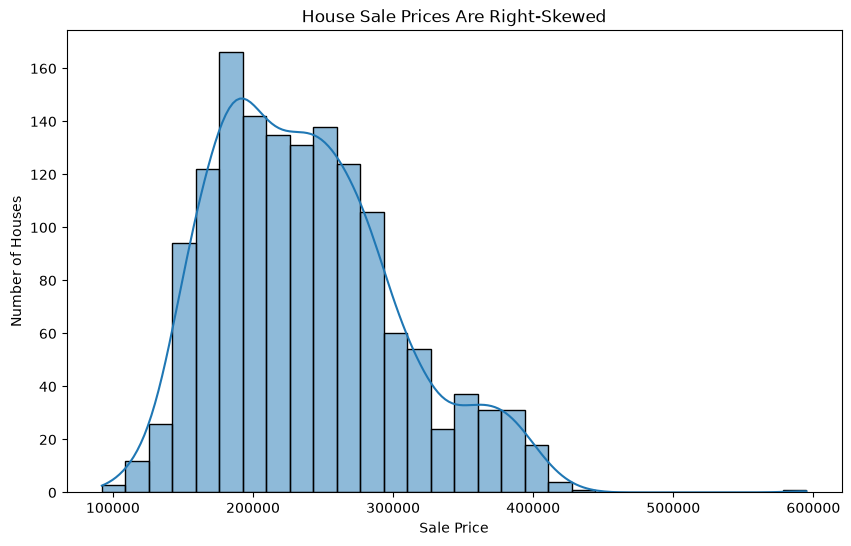

In [54]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="SalePrice",
    bins=30,
    kde=True
)

plt.title("House Sale Prices Are Right-Skewed")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.savefig("figures/chart_01_saleprice_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

The SalePrice distribution is right-skewed, with most houses
concentrated at lower and middle price levels and a smaller number of
higher-priced properties forming a long right tail.

## 6.2 Living Area and Sale Price

### Question
Is above-ground living area associated with house sale price?

### Why this chart?
A scatter plot is appropriate because both `GrLivArea` and `SalePrice`
are continuous numeric variables, allowing us to see the direction,
strength, and unusual observations in their relationship.

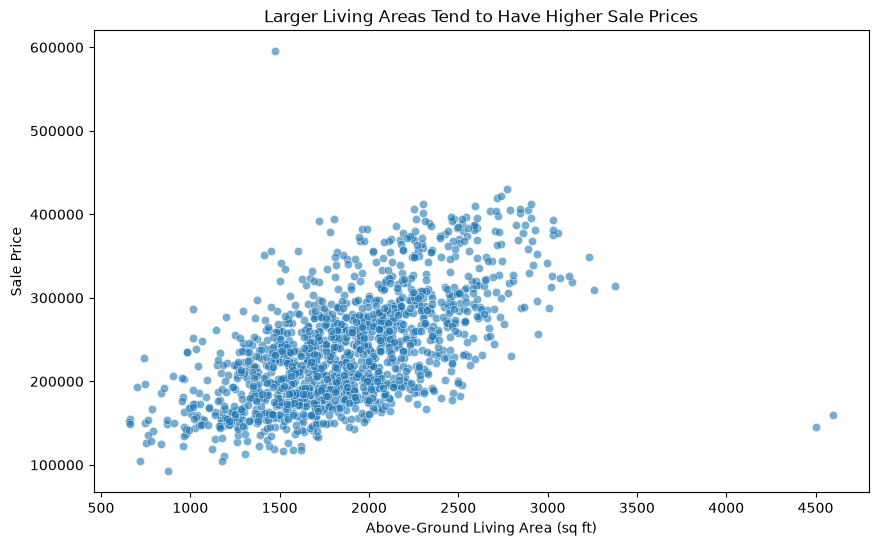

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="GrLivArea",
    y="SalePrice",
    alpha=0.6
)

plt.title("Larger Living Areas Tend to Have Higher Sale Prices")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.savefig("figures/chart_02_grlivarea_saleprice.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

There is a clear positive association between above-ground living
area and sale price. In general, houses with larger living areas tend
to have higher sale prices. However, the relationship is not perfect,
and several observations deviate substantially from the overall
pattern, indicating the presence of potential outliers.

## 6.3 Sale Price Across Neighborhoods

### Question
How does the typical sale price vary across neighborhoods?

### Why this chart?
A bar chart is useful for comparing a single summary statistic
across categorical groups. Median sale price is used because house
prices are skewed and the median is less affected by extreme values.

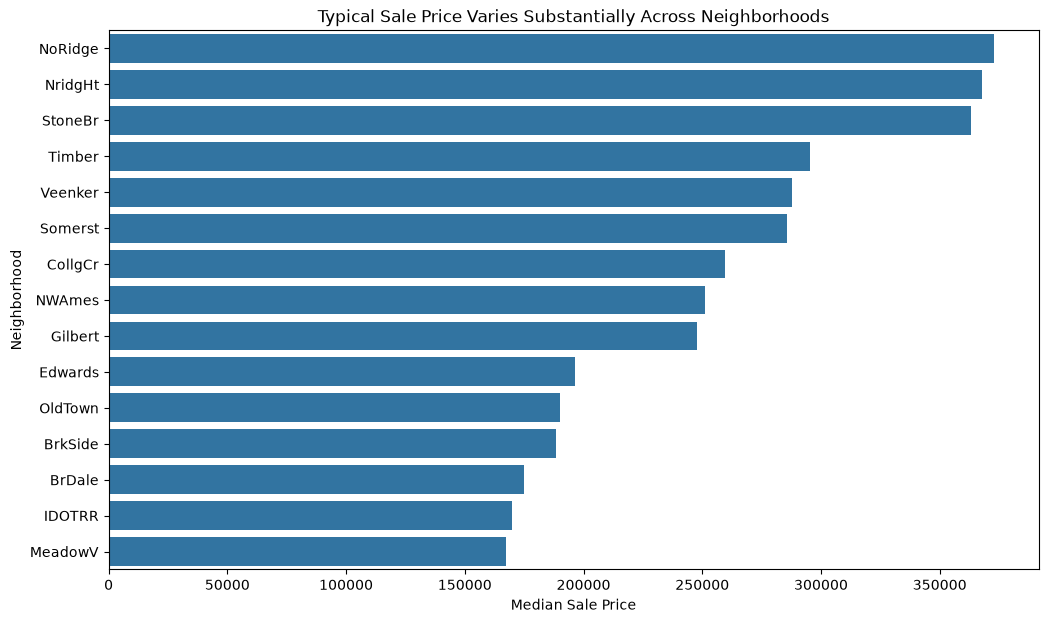

In [56]:
neighborhood_median = (
    df_clean
    .groupby("Neighborhood")["SalePrice"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=neighborhood_median.values,
    y=neighborhood_median.index
)

plt.title("Typical Sale Price Varies Substantially Across Neighborhoods")
plt.xlabel("Median Sale Price")
plt.ylabel("Neighborhood")

plt.savefig("figures/chart_03_neighborhood_median.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

Median sale price varies substantially across neighborhoods. NoRidge
has the highest median sale price, while MeadowV has the lowest among
the neighborhoods shown. This indicates that neighborhood is strongly
associated with differences in typical house prices.

## 6.4 Overall Quality and Sale Price

### Question
How does overall house quality relate to sale price?

### Why this chart?
A box plot is appropriate because `OverallQual` is an ordered
categorical/discrete variable and `SalePrice` is continuous. It allows
us to compare both the center and spread of sale prices across quality
levels.

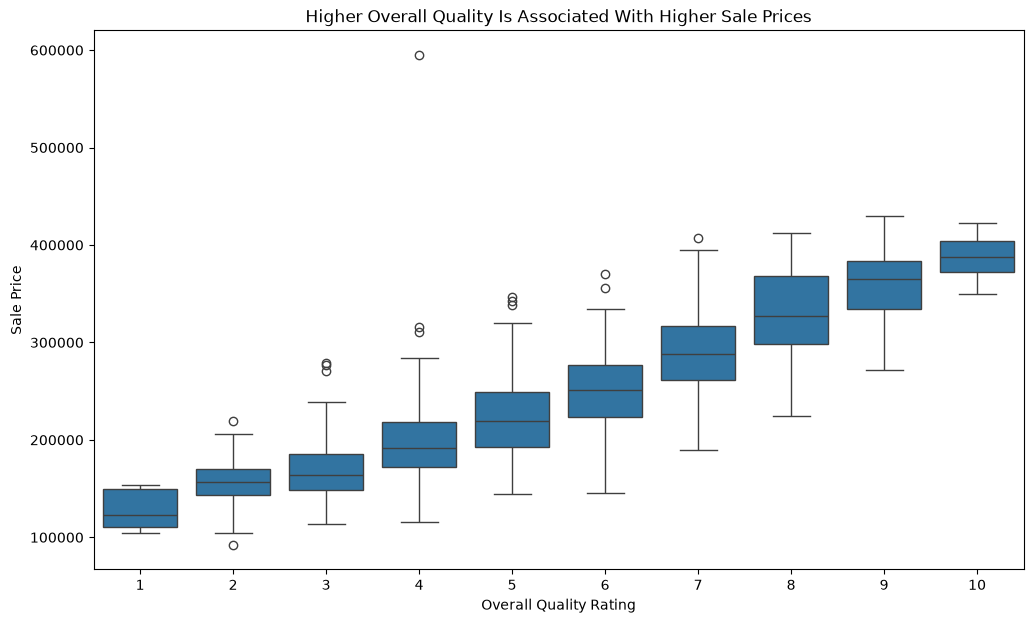

In [57]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_clean,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Higher Overall Quality Is Associated With Higher Sale Prices")
plt.xlabel("Overall Quality Rating")
plt.ylabel("Sale Price")

plt.savefig("figures/chart_04_quality_saleprice.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

Sale prices generally increase as the overall quality rating rises.
Higher-quality homes have both higher typical prices and a different
range of observed sale prices than lower-quality homes.

## 6.5 Living Area, Sale Price, and Overall Quality

### Question
Does the relationship between living area and sale price differ
across overall quality levels?

### Why this chart?
A scatter plot with a third variable encoded by color allows us to
examine whether the relationship between two continuous variables
changes across quality groups.

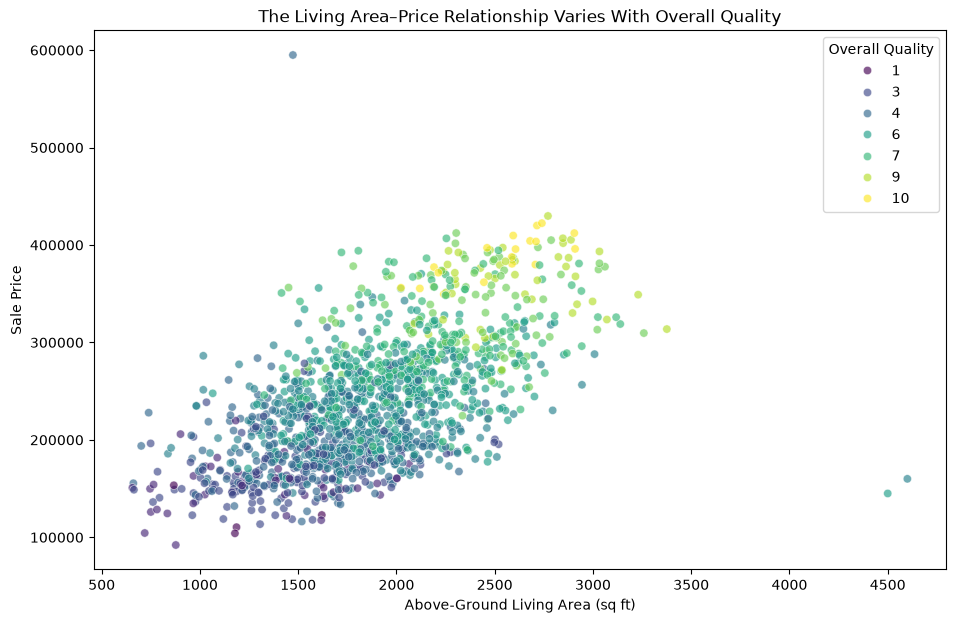

In [58]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_clean,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    palette="viridis",
    alpha=0.65
)

plt.title("The Living Area–Price Relationship Varies With Overall Quality")
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.legend(title="Overall Quality")

plt.savefig("figures/chart_05_area_quality_saleprice.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

The positive relationship between living area and sale price is
visible across different quality levels. However, houses with higher
overall quality generally occupy higher sale-price ranges than houses
with lower quality at similar living areas. This suggests that overall
quality provides additional information beyond living area when
examining sale price.

## 6.6 Numeric Feature Correlations

### Question
Which numeric variables have the strongest linear relationships
with SalePrice and with each other?

### Why this chart?
A correlation heatmap provides a compact view of the direction and
strength of pairwise linear relationships across multiple numeric
variables.

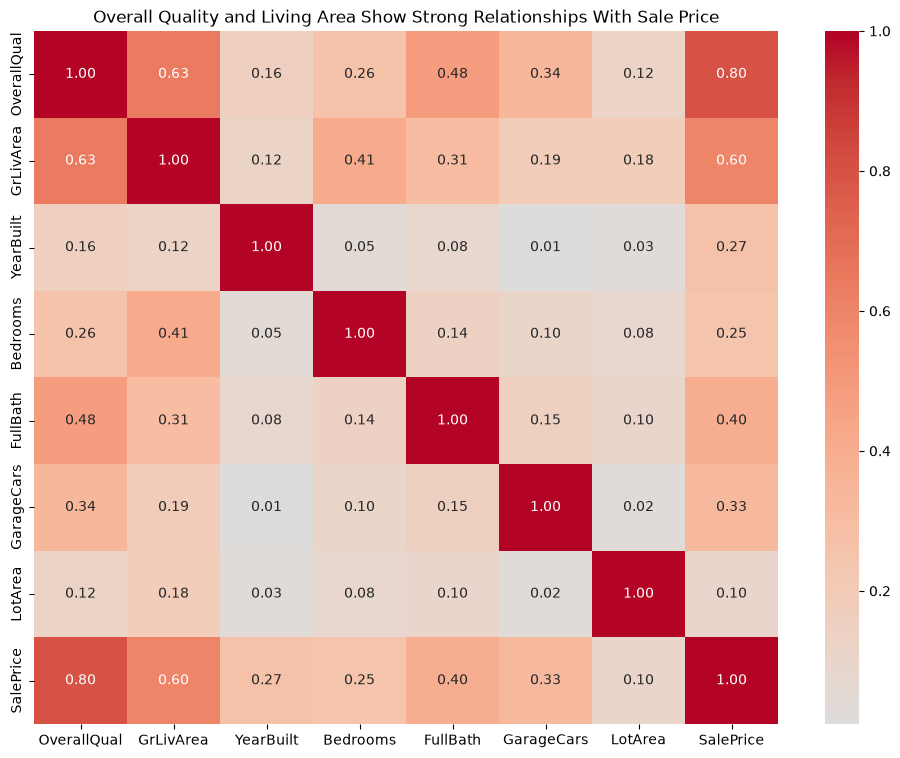

In [59]:
numeric_df = df_clean.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Overall Quality and Living Area Show Strong Relationships With Sale Price")
plt.savefig("figures/chart_06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

OverallQual has the strongest positive correlation with SalePrice
among the variables shown (r = 0.80), followed by GrLivArea
(r = 0.60). Other variables such as FullBath, GarageCars, and
YearBuilt show weaker positive correlations. These results describe
linear association and should not be interpreted as evidence of
causation.

## 6.7 Hypothesis Test 1 — Sale Price by Quality Group

### Question
How different are sale prices between the high-quality and
low/medium-quality groups used in Hypothesis Test 1?

### Why this chart?
A box plot allows direct comparison of the distributions, medians,
spread, and potential outliers between the two groups tested
statistically.

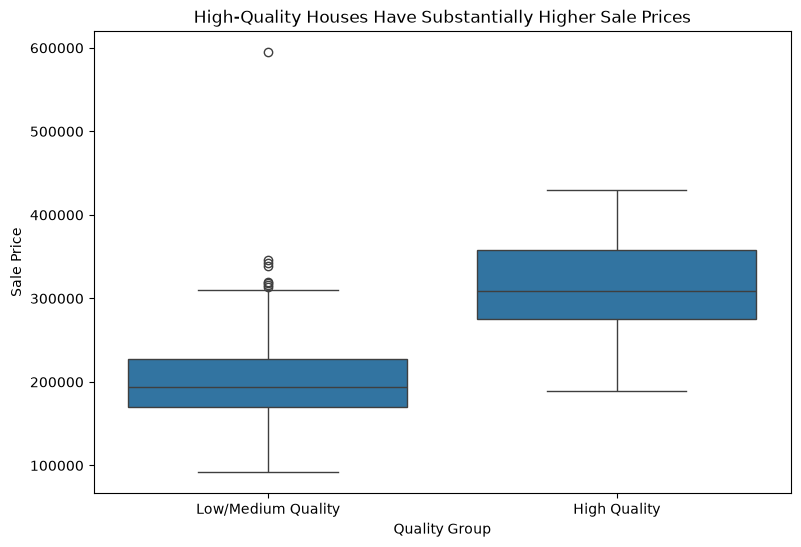

In [60]:
quality_groups = df_clean.copy()

quality_groups["QualityGroup"] = np.where(
    quality_groups["OverallQual"] >= 7,
    "High Quality",
    np.where(
        quality_groups["OverallQual"] <= 5,
        "Low/Medium Quality",
        "Quality 6"
    )
)

plot_data = quality_groups[
    quality_groups["QualityGroup"].isin(
        ["High Quality", "Low/Medium Quality"]
    )
]

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=plot_data,
    x="QualityGroup",
    y="SalePrice"
)

plt.title("High-Quality Houses Have Substantially Higher Sale Prices")
plt.xlabel("Quality Group")
plt.ylabel("Sale Price")

plt.savefig("figures/chart_07_quality_groups.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

The high-quality group has a substantially higher typical sale price
than the low/medium-quality group. This visual pattern is consistent
with the Welch's t-test, which found an extremely strong statistical
difference and a very large effect size (Cohen's d = 2.505).

## 6.8 Hypothesis Test 2 — Sale Price Across Neighborhoods

### Question
How does the distribution of sale prices vary across neighborhoods?

### Why this chart?
A box plot is appropriate for comparing the distribution, median,
spread, and outliers of a continuous variable across multiple
categorical groups.

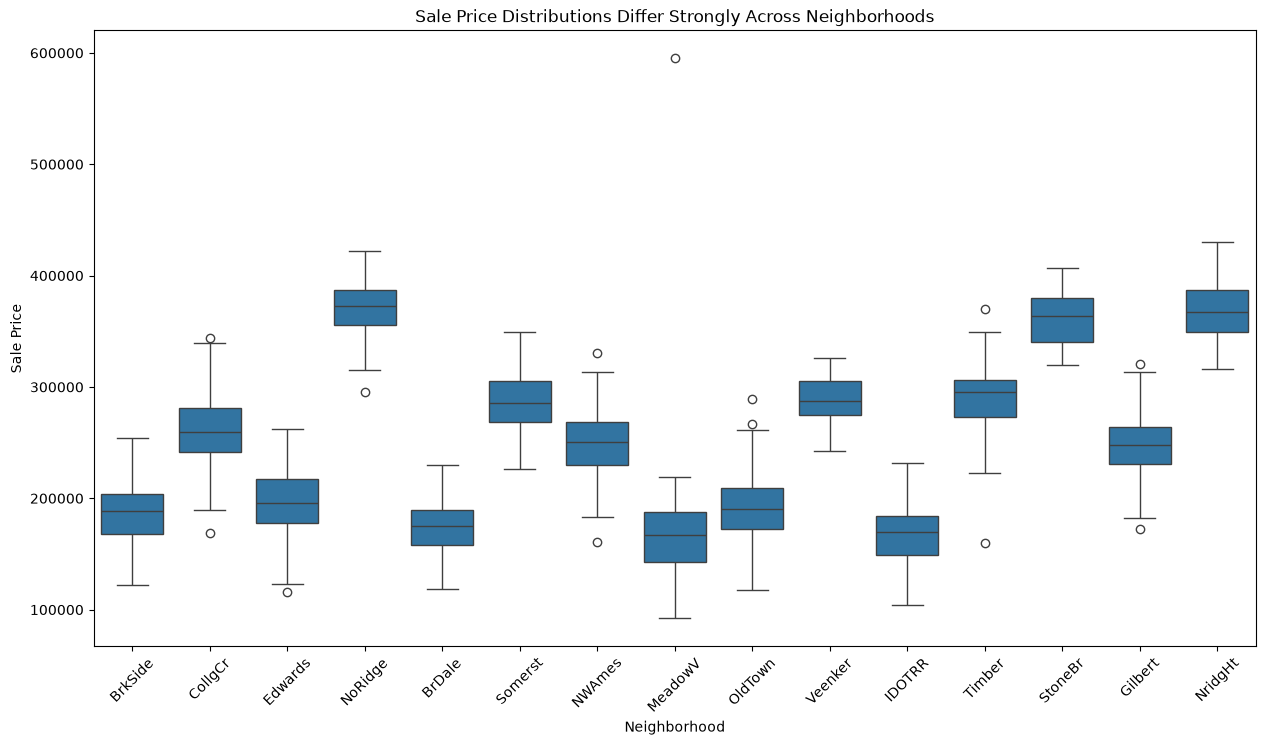

In [61]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=df_clean,
    x="Neighborhood",
    y="SalePrice"
)

plt.title("Sale Price Distributions Differ Strongly Across Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price")

plt.xticks(rotation=45)

plt.savefig("figures/chart_08_neighborhood_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


### Conclusion

Sale price distributions vary substantially across neighborhoods,
with some neighborhoods showing consistently higher typical sale
prices than others. This visual pattern is consistent with the
one-way ANOVA result (F = 400.101, p < 0.001) and the very large
effect size (η² = 0.795).

# 7. Final Key Findings

1. `OverallQual` has the strongest observed linear relationship with
   `SalePrice` among the selected numeric variables (r ≈ 0.80).
2. `GrLivArea` also has a strong positive association with `SalePrice`
   (r ≈ 0.60).
3. High-quality houses have substantially higher mean sale prices than
   low/medium-quality houses, with a very large effect size (Cohen's
   d = 2.505).
4. Sale prices differ strongly across neighborhoods, with a very large
   association measured by η² = 0.795.
5. The relationship between living area and sale price is not explained
   by living area alone; overall quality shifts the price range.

# 8. Limitations

- This is observational data, so the analysis identifies associations
  rather than proving causation.
- Some neighborhoods have fewer observations than others, so estimates
  for small groups may be less stable.
- `LotFrontage` was removed because of missingness and because it was not
  essential to the primary questions. A different reasonable decision,
  such as neighborhood-based imputation, could change some secondary
  findings.
- The analysis uses a selected set of property variables, so other
  unobserved factors may also explain sale-price differences.
- Statistical significance does not by itself imply economic or practical
  importance; effect sizes were therefore reported alongside p-values.
- The quality-group test excludes Quality 6 (293 houses) to compare clearly
  separated groups. This can inflate the effect size, so a sensitivity check
  that includes Quality 6 is reported in Section 5.1.
- `SalePrice` is right-skewed and Shapiro-Wilk rejects strict normality for
  both quality groups and for MeadowV and Timber. Welch's t-test and ANOVA are
  used as robust mean-comparison methods because the groups are reasonably
  large, but this assumption is not perfectly satisfied.


# 9. Final Conclusion

The Ames Housing analysis shows that overall quality, living area, and
neighborhood are strongly associated with house sale prices. The two
hypothesis tests provide strong statistical evidence for meaningful
differences in sale prices, and the effect sizes indicate that the
observed differences are also practically substantial.

The project demonstrates an end-to-end analytical workflow: framing a
question, assessing data quality, making and defending cleaning decisions,
exploring patterns, testing hypotheses, checking assumptions, measuring
effect sizes, and communicating findings through final visualizations.

**Important:** The results describe this dataset and should not be
interpreted as universal causal rules about house prices.